In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Two titration curves, and why all the chemistry is on the left half (Illustrations 13.5-2 and 13.5-8)

Ten milliliters of a 0.20-M acid, titrated with 0.20-M NaOH. Section 13.5 does this twice
-- once with hydrochloric acid (Illustration 13.5-2) and once with acetic acid
(Illustration 13.5-8) -- and then says *"it is of interest to compare"* them. It is, and
the comparison is the reason both illustrations exist rather than one.

**Everything after the equivalence point is identical.** Past 10 mL there is no acid left
of either kind, only excess NaOH in a growing volume, and the two curves lie on top of
each other. All the chemistry is on the left half.

Before the equivalence point the two are completely different objects:

* the strong acid is pure bookkeeping -- count the H$^+$ that have not yet been
  neutralized and divide by the volume;
* the weak acid needs Eq. 13.5-16, because how much of it has dissociated depends on how
  much base has been added, which is the thing being varied.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.ionization import WeakAcid, titration_strong_acid, titration_weak_acid
from thermo.charts import use_book_style

use_book_style()

V_ACID, M_ACID, M_BASE = 10.0, 0.20, 0.20      # mL, molal, molal -- both illustrations
acetic = WeakAcid(4.76)                        # Illustration 13.5-8
EQUIV = V_ACID * M_ACID / M_BASE               # 10 mL


## The strong acid, by hand and by equation

The illustration works three points by hand. They are the right three points to check any
titration routine against: one before the equivalence point, the equivalence point
itself, and one after.


In [3]:
print("Illustration 13.5-2, the three points it works by hand")
print(f"  X = 0 mL    pH = {titration_strong_acid(0.0):.3f}     book: 0.70")
print(f"  X = 1 mL    pH = {titration_strong_acid(1.0):.3f}     book: 0.786")
print(f"  X = 10 mL   pH = {titration_strong_acid(10.0):.3f}     book: 7 (by definition)")
print(f"  X = 15 mL   pH = {titration_strong_acid(15.0):.3f}    book: 12.60")

print("\nthe hand calculation at X = 15 mL, step by step:")
n_excess = 15.0 * M_BASE - V_ACID * M_ACID
print(f"  OH- left over            {n_excess:.3f} mmol in {V_ACID + 15:.0f} mL")
print(f"  M_OH-                    {n_excess / (V_ACID + 15):.3f} M      book: 0.04 M")
print(f"  M_H+ = 1e-14 / M_OH-     {1e-14 / (n_excess / (V_ACID + 15)):.4g} M   book: 0.25e-12 M")


Illustration 13.5-2, the three points it works by hand
  X = 0 mL    pH = 0.699     book: 0.70
  X = 1 mL    pH = 0.786     book: 0.786
  X = 10 mL   pH = 7.000     book: 7 (by definition)
  X = 15 mL   pH = 12.602    book: 12.60

the hand calculation at X = 15 mL, step by step:
  OH- left over            1.000 mmol in 25 mL
  M_OH-                    0.040 M      book: 0.04 M
  M_H+ = 1e-14 / M_OH-     2.5e-13 M   book: 0.25e-12 M


Two unit slips in the illustration's arithmetic, neither of which changes an answer:
0.20 M $\times$ 0.001 L is **0.2 mmol** of NaOH, not the "0.0002 mmol" printed twice; and
0.001 mol / 0.025 **mL** should read 0.025 L. The numbers that follow are computed
correctly from the intended values.


## The weak acid, and the equation that looks like a typo

For a weak acid partly neutralized by a strong base, Eq. 13.5-16 gives

$$M_{\mathrm{H^+}}=\frac{-\left(K_{\rm HA}+M_{\rm BOH}\right)
 +\sqrt{\left(K_{\rm HA}-M_{\rm BOH}\right)^{2}+4K_{\rm HA}M_{\rm HA,o}}}{2}$$

The **plus** outside the radical and the **minus** inside it. That asymmetry is real, and
it is exactly the sort of thing a reader corrects by
mistake. It comes from substituting Eq. 13.5-15 for $\alpha$ into
$M_{\mathrm{H^+}}=\alpha M_{\rm HA,o}-M_{\rm BOH}$: the $-M_{\rm BOH}$ that arrives from
Eq. 13.5-15 and the $-M_{\rm BOH}$ subtracted afterwards add, while the radical is
untouched.

**Illustration 13.5-7 sets it with a plus in both places**, and the number it prints
comes from the correct form:


In [4]:
K, B, M0 = acetic.K, 0.07, 0.1
right = (-(K + B) + np.sqrt((K - B) ** 2 + 4 * K * M0)) / 2
wrong = (-(K + B) + np.sqrt((K + B) ** 2 + 4 * K * M0)) / 2
print(f"  Eq. 13.5-16, (K - M_BOH)^2 :  M_H+ = {right:.5g}   pH = {-np.log10(right):.3f}")
print(f"  Ill. 13.5-7, (K + M_BOH)^2 :  M_H+ = {wrong:.5g}   pH = {-np.log10(wrong):.3f}")
print(f"  the illustration prints    :  M_H+ = 7.445e-6      pH = 5.128")

print("\nthe two roots differ by a factor of 3.3 in M_H+, and 0.52 in pH -- so the")
print("typo is not cosmetic, it just happens not to have reached the printed answer.")


  Eq. 13.5-16, (K - M_BOH)^2 :  M_H+ = 7.4451e-06   pH = 5.128
  Ill. 13.5-7, (K + M_BOH)^2 :  M_H+ = 2.4811e-05   pH = 4.605
  the illustration prints    :  M_H+ = 7.445e-6      pH = 5.128

the two roots differ by a factor of 3.3 in M_H+, and 0.52 in pH -- so the
typo is not cosmetic, it just happens not to have reached the printed answer.


### The catastrophic cancellation hiding in that expression

At the conditions of Illustration 13.5-7, $K_{\rm HA}=1.74\times10^{-5}$ and
$M_{\rm BOH}=0.07$. The two terms of the numerator are 0.070017 and 0.070032; their
difference is $1.5\times10^{-5}$. **Four of the six significant figures cancel.**

That is why the illustration's answer and a careful recomputation differ in the fourth
digit, and it is a good reason to prefer the algebraically equivalent form that never
subtracts near-equal numbers.


In [5]:
a = -(K + B)
b = np.sqrt((K - B) ** 2 + 4 * K * M0)
print(f"  -(K + M_BOH)     = {a:.10f}")
print(f"  sqrt(...)        = {b:.10f}")
print(f"  their sum        = {a + b:.10e}   <- 4 of 6 digits gone")
# the stable rearrangement: multiply above and below by the conjugate
stable = 2 * K * (M0 - B) / (-a + b) if M0 != B else np.nan
print(f"\n  M_H+ direct      = {(a + b) / 2:.10e}")
print(f"  M_H+ stable form = {stable:.10e}   (same algebra, no cancellation)")


  -(K + M_BOH)     = -0.0700173780
  sqrt(...)        = 0.0700322682
  their sum        = 1.4890155395e-05   <- 4 of 6 digits gone

  M_H+ direct      = 7.4450776974e-06
  M_H+ stable form = 7.4450776974e-06   (same algebra, no cancellation)


## Both curves

The comparison the section asks for. `titration_weak_acid` uses Eq. 13.5-16 on the
concentrations *as diluted by the base solution added* -- the dilution matters, and the
illustration writes it out explicitly.


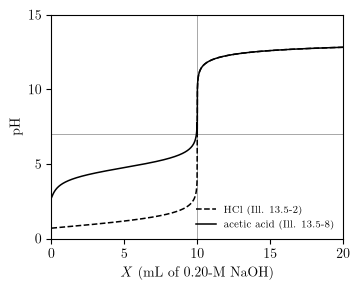

  starting pH   strong 0.699   weak 2.732
  at X = 5 mL   strong 1.176   weak 4.760
  at X = 15 mL  strong 12.602  weak 12.602

  the two branches past 10 mL agree to 0 pH units


In [6]:
X = np.linspace(0.0, 20.0, 2001)
pH_strong = titration_strong_acid(X, V_ACID, M_ACID, M_BASE)
pH_weak = titration_weak_acid(X, acetic, V_ACID, M_ACID, M_BASE)

fig, ax = plt.subplots(figsize=(3.7, 3.0))
ax.plot(X, pH_strong, "--", color="k", lw=1.1, label="HCl (Ill. 13.5-2)")
ax.plot(X, pH_weak, "-", color="k", lw=1.1, label="acetic acid (Ill. 13.5-8)")
ax.axhline(7.0, color="0.6", lw=0.6, zorder=0)
ax.axvline(EQUIV, color="0.6", lw=0.6, zorder=0)
ax.set_xlabel(r"$X$  (mL of 0.20-M NaOH)"); ax.set_ylabel("pH")
ax.set_xlim(0, 20); ax.set_ylim(0, 15); ax.set_yticks([0, 5, 10, 15])
ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()

print(f"  starting pH   strong {pH_strong[0]:.3f}   weak {pH_weak[0]:.3f}")
print(f"  at X = 5 mL   strong {np.interp(5, X, pH_strong):.3f}   weak {np.interp(5, X, pH_weak):.3f}")
print(f"  at X = 15 mL  strong {np.interp(15, X, pH_strong):.3f}  weak {np.interp(15, X, pH_weak):.3f}")
print("\n  the two branches past 10 mL agree to "
      f"{np.max(np.abs(pH_strong[X > 10.5] - pH_weak[X > 10.5])):.2g} pH units")


Read the left half. The weak acid starts two pH units higher, and then it *resists*: over
the first 8 mL its pH rises by only about 1.5 units, because every hydroxide added simply
converts one HAc into one Ac$^-$ and the ratio in the Henderson-Hasselbalch equation moves
logarithmically. The strong acid has no such reservoir; its pH is set directly by what is
left.

**The buffer region is centered on p$K_{\rm HA}$.** At the half-equivalence point, $X=5$ mL,
exactly half the acetic acid has been converted, $M_{\rm Ac^-}=M_{\rm HAc}$, and the pH is
p$K_{\rm HA}$ -- which is how p$K$ values are measured.


In [7]:
print(f"  pH at the half-equivalence point, X = {EQUIV/2:g} mL: "
      f"{np.interp(EQUIV/2, X, pH_weak):.3f}")
print(f"  pK_HA of acetic acid:                       {acetic.pKa:.3f}")


  pH at the half-equivalence point, X = 5 mL: 4.760
  pK_HA of acetic acid:                       4.760


## The printed pH formula past the equivalence point is undefined

Illustration 13.5-8 gets the hydroxide balance right --
$M_{\rm OH^-}=(0.2X-2)/(10+X)$, with the 2 mmol that neutralized the acid subtracted --
and then gets the hydrogen ion molality right,
$M_{\rm H^+}=(10+X)\times10^{-14}/(0.2X-2)$. Two lines later it prints

$$\mathrm{pH}=-\log\left[\frac{(10-X)\times10^{-14}}{2X-2}\right]$$

**The argument is negative for every $X>10$ mL**, which is the entire range the equation
is written for. Two independent slips: $(10-X)$ for $(10+X)$, and a denominator multiplied
by ten without the numerator.

The figure printed beside it is correct, so this is a typesetting failure and not a
calculation error -- but it is the kind a student will spend an hour on.


In [8]:
Xa = np.array([12.0, 15.0, 20.0])
print(f"{'X (mL)':>7} {'M_H+ correct':>14} {'pH':>8} {'printed log argument':>22}")
for x in Xa:
    good = (10 + x) * 1e-14 / (0.2 * x - 2)
    bad = (10 - x) * 1e-14 / (2 * x - 2)
    print(f"{x:7.1f} {good:14.4g} {-np.log10(good):8.3f} {bad:22.4g}   negative")

with np.errstate(invalid="ignore", divide="ignore"):
    printed = titration_weak_acid(X, acetic, V_ACID, M_ACID, M_BASE, printed=True)
print(f"\n  the printed branch returns NaN at {np.isnan(printed[X > EQUIV]).sum()} "
      f"of the {int((X > EQUIV).sum())} points past the equivalence point")


 X (mL)   M_H+ correct       pH   printed log argument
   12.0        5.5e-13   12.260             -9.091e-16   negative
   15.0        2.5e-13   12.602             -1.786e-15   negative
   20.0        1.5e-13   12.824             -2.632e-15   negative

  the printed branch returns NaN at 1000 of the 1000 points past the equivalence point


## Your turn

1. The Comment on Illustration 13.5-2 says the simple equations "lead to
   $M_{\rm H^+}=0$ and a singularity in the pH" at the neutral point, while Eq. 13.5-7b
   does not. Plot both across $9.9<X<10.1$ mL and show the difference.
2. Redo the acetic acid curve including the ion activity coefficients, using the extended
   Debye-Huckel law with the ionic strength from *all* the ions present -- which by the
   equivalence point is dominated by Na$^+$ and Ac$^-$. How far does the curve move?
3. The sharpness of the jump at the equivalence point is what lets an indicator work.
   Compute $\mathrm{d\,pH}/\mathrm{d}X$ at $X=10$ mL for both acids, then repeat for a
   0.002-M acid instead of 0.20-M. At what concentration does the strong-acid titration
   stop being sharp enough to see?
4. Titrate a *weak base* with a strong acid instead. Problem 13.58 asks for the equation;
   derive it, and then check your derivation by confirming that the curve is the mirror
   image of the acetic acid curve above -- Illustration 13.5-8's -- about pH 7 when the
   p$K_b$ equals 14 minus the acetic p$K_a$.
5. Diprotic acids give two jumps. Using Sec. 13.6's phthalic acid (p$K_1$ = 2.95,
   p$K_2$ = 5.41), predict how many jumps its titration curve shows and at what pH,
   before computing it.
